<a href="https://colab.research.google.com/github/lawanmuk/hbn-parabolic-two-band-model/blob/main/FT_analysis_current.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Code that performs the fourier transforms of laser and the current to calculate optical conductivity σ(ω)and dielectric function ϵ(ω).

In [ ]:
!pip install anonfile > /dev/null
from anonfile import AnonFile

anon = AnonFile()
filename = anon.download("https://anonfiles.com/G3a2K6G7y2/prim_15153_laser", path='.')
filename_2 = anon.download("https://anonfiles.com/1ab5K3G4y5/prim_15153_total_current", path='.')

TypeError: ignored

#Analyse

In [ ]:
import sys
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec


# Input Parameters

In [ ]:
H2ev = 27.211385              #Convert Hartree to eV
f  = 163.10553149492998/H2ev  #201.8839888944/H2ev  which is the kedge to calculate the
c = 137.03604                 #speed of light in a.u


# Load laser file and the current file.

In [ ]:
probe_data = np.loadtxt("prim_15153_laser") #laser for prim_cell_lda
time_laser = probe_data[:, 1]               #time steps
probe = probe_data[:, 2]                    #probe field


total_current = np.loadtxt("prim_15153_total_current")  #current for prim_cell_lda
time_cr = total_current[:, 1]
current = total_current[:, 2]

#Cut off the laser time at the maximum of the signal time.

In [ ]:
Tf_ind = len(time_cr)
time_laser = time_laser[:Tf_ind]
probe = probe[:Tf_ind]


# Calculating the derivative of the vector potential to get the Electric field
$$
\mathbf{E}=-\frac{1}{c} \frac{\partial \mathbf{A}}{\partial t}
$$


In [ ]:
field = -(1.0/c)*np.gradient(probe, time_laser[1]-time_laser[0])
Tz_ind = len(time_laser)
field = field[:Tz_ind]

# Plot of laser, field and Total Current

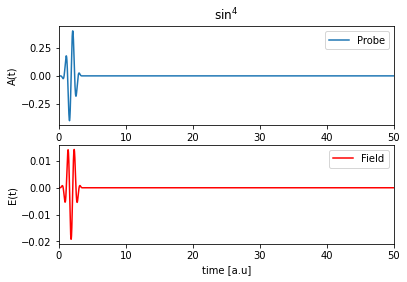

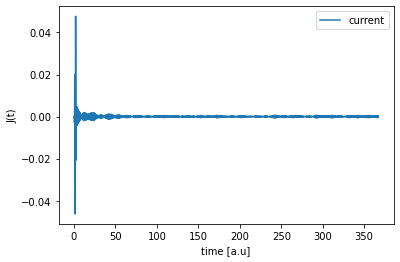

In [ ]:
plt.figure(1)
plt.subplot(2, 1, 1)
plt.title(r"$\sin^{4}$")
plt.plot(time_laser, probe, label="Probe")
plt.xlim([0, 50])
plt.ylabel("A(t)")
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(time_laser, field, label="Field", color="r")
plt.xlabel("time [a.u]")
plt.ylabel("E(t)")
plt.xlim([0, 50])
plt.legend()

plt.figure(2)
plt.plot(time_cr, current, label="current")
plt.xlabel("time [a.u]")
plt.ylabel(r"J(t)")
plt.legend()


# Time and Energy axis

In [ ]:
time_dt = time_cr[1] - time_cr[0]
energy = np.arange(f - 0.5 * f, f + 0.5 * f, f / 5000)

# Performing Fourier Transforms
$$
F(\omega)=\int_{-\infty}^{+\infty} f(t) e^{-i \omega t} d t
$$

In [ ]:
def FT(time_cr, current, probe, energy):
    global time_dt
    sigOutNum = np.zeros(len(energy)).astype(np.complex128)
    sigOutDenom = np.zeros(len(energy)).astype(np.complex128)
    kappa_cr = 0.25 / H2ev  # -np.log(1e-2)/time_cr[-1] #0.25/H2ev
    mask_cr = np.exp(-kappa_cr * time_cr)

    current_tmp = current * mask_cr
    probe_tmp = probe * mask_cr

    for ei, e in enumerate(energy):
        sigOutNum[ei] = np.sum(np.exp(1j * e * time_cr) * current_tmp) * time_dt
        sigOutDenom[ei] = np.sum(np.exp(1j * e * time_cr) * probe_tmp) * time_dt

    return sigOutNum, sigOutDenom

aCurrent, aLaser = FT(time_cr, current, field, energy)

# Evaluate the optical conductivity
\begin{equation}
\sigma(\omega)=\frac{{J(ω)}}{E({\omega})}
\end{equation}

In [ ]:
sigma = aCurrent / aLaser

# Plot of optical conductivity

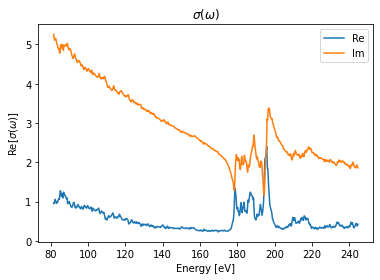

In [ ]:
plt.figure(3)
plt.plot(energy * H2ev, -1.0 * np.real(sigma), linestyle="-", label="Re")
plt.plot(energy * H2ev, -1.0 * np.imag(sigma), linestyle="-", label="Im")
plt.legend()
plt.xlabel("Energy [eV]")
plt.ylabel(r"Re[$\sigma(\omega)$]")
plt.title(r"$\sigma(\omega)$")
plt.show()


# Plots of various functions of sigma


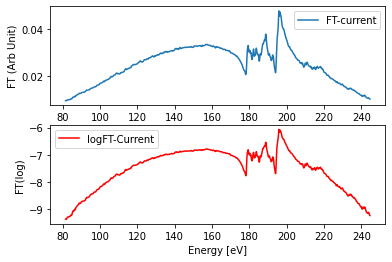

In [ ]:
plt.figure(4)
plt.subplot(2, 1, 1)
#plt.plot(energy * H2ev, np.abs((aLaser)), label="FT-Laser")
plt.plot(energy * H2ev, np.abs((aCurrent)), label="FT-current")
plt.xlabel("Energy [eV]")
plt.ylabel("FT (Arb Unit)")
plt.legend()
plt.subplot(2, 1, 2)
#plt.plot(energy * H2ev, np.log(np.abs((aLaser)) ** 2), label="logFT-Laser")
plt.plot(energy * H2ev, np.log(np.abs(aCurrent) ** 2), 'r', label="logFT-Current")
plt.xlabel("Energy [eV]")
plt.ylabel("FT(log)")
plt.legend()
plt.show()

# Evaluating the dieclectric function
$$\varepsilon(\omega)=1+\mathrm{i}\frac{ 4\pi  \sigma(\omega)}{\omega}$$

In [ ]:
eps = -1.0 * np.imag(
    1 + 4 * np.pi * 1j * aCurrent / (aLaser * energy)
)

# Plotting Dielectric function

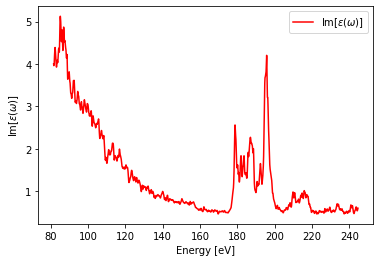

In [ ]:
plt.figure(5)
plt.clf()
plt.plot(energy * H2ev, eps, label=r"Im[$\epsilon(\omega)$]", color="r")
plt.legend()
plt.xlabel("Energy [eV]")
plt.ylabel(r"Im[$\epsilon(\omega)$]")
plt.show()

#Comparison between conductivity and dielectric function

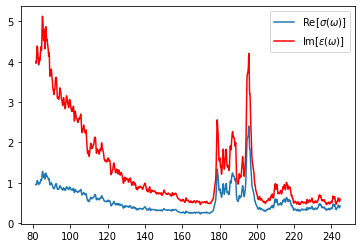

In [ ]:
plt.figure(5)
plt.plot(
    energy * H2ev, -1.0 * np.real(sigma), linestyle="-", label=r"Re[$\sigma(\omega)$]"
)
plt.plot(energy * H2ev, eps, label=r"Im[$\epsilon(\omega)$]", color="r")
plt.legend()
plt.show()
